In [ ]:
!apt-get update
!apt-get install g++ openjdk-8-jdk
!pip3 install konlpy

In [ ]:
from google.colab import files
myfile = files.upload()

Saving korean_stopword.csv to korean_stopword.csv


In [ ]:
!pip install gdown
!gdown --id 15kGgL0GGkzZdUzlJZwayDzHA7HZ9hoqW --output /content/newsData.zip

In [ ]:
!unzip -qq '/content/newsData.zip' -d '/content/'

In [ ]:
# 데이터 카테고리
# 0: 정치 (policy)
# 1: 경제 (economy)
# 2: 사회 (social)
# 3: 생활/문화 (culture)
# 4: 세계 (international)
# 5: 과학 (science)
# 6: 연애 (ENT)
# 7. 스포츠 (sports)

In [ ]:
import os
import pandas as pd
import re

folders = ["/content/0", "/content/1", "/content/2", "/content/3",
           "/content/4", "/content/5", "/content/6", "/content/7"]

data_list = []

def remove_text(text):
    return re.sub(r'[^a-zA-Z0-9가-힣\s]', '', text)

for folder in folders:
  label = int(os.path.basename(folder))
  for filename in os.listdir(folder):
      file_path = os.path.join(folder, filename)
      if os.path.isfile(file_path) and filename.endswith('.txt'):
          with open(file_path, 'r', encoding='utf-8') as file:
              content = file.read().strip()
              content = content.replace('\n', ' ').replace('\t', ' ')
              content = remove_text(content)
              data_list.append({'data': content, 'label': label})

df = pd.DataFrame(data_list)

df.head(5)

,data,label
0,조명균 에 전통문 보낼 것내용은 검토 중 이제 시작단계중요한 것은 이런 상황에서도 ...,0
1,문재인 정부 첫 특검 합의 법안 명칭서 김경수대선은 빠져 동아일보 18일 특검추경 ...,0
2,앞뒤 안맞는 회담 연기 배경북 강경파 달래기위한 대내용 앵커 북한이 이처럼 맥스썬...,0
3,남북미 갈등에 고심했던 적극적 중재 역할에 기대감 메시지 분석 끝낸 신중모드적극적 ...,0
4,단독 김기식 단독출장 문제삼더니의원 20여명 나홀로 출장 나홀로 출장에 여야 구분 ...,0


In [ ]:
selected_files = ['0188NewsData.txt', '0108NewsData.txt', '0186NewsData.txt']

print(selected_files)

['0188NewsData.txt', '0108NewsData.txt', '0186NewsData.txt']


In [ ]:
# 파일 읽기
f = open('/content/0/0186NewsData.txt', 'r', encoding='utf-8')
data = f.read()
print(data)

경찰, '구치소 접견조사 거부' 드루킹 체포영장 신청	(서울=연합뉴스) 임기창 기자 = 네이버 댓글 여론조작 사건을 수사하는 서울지방경찰청은 구치소 접견조사를 거부하는 '드루킹' 김모(49, 구속기소)씨를 추가 조사하고자 9일 체포영장을 신청했다.

경찰은 앞서 지난 3월 말 드루킹을 구속 송치한 이후 4월17일과 19일 2차례 서울구치소에서 그를 접견조사했다. 그러나 드루킹은 이달 3일부터는 경찰이 3차례 시도한 접견조사를 모두 거부했다.

경찰은 드루킹이 작년 대선 이후 더불어민주당 김경수 의원에게 특정인 인사를 청탁한 뒤 그와 관련한 편의를 얻고자 김 의원 보좌관 한모씨에게 500만원을 준 사실을 확인한 만큼 드루킹에 대한 추가 조사가 불가피하다는 입장이다.

경찰은 드루킹과 한씨의 금품거래에 뇌물 혐의를 적용할 수 있는지 등을 판단하고자 드루킹을 상대로 돈을 건넨 목적과 경위 등을 확인하겠다는 방침이다.

구치소에 수감된 피의자를 강제조사하고자 경찰이 체포영장을 신청하는 일은 드물다.


In [ ]:
df.shape

(1600, 2)

In [ ]:
filtered_df = df[df['data'].str.contains('드루킹')]

filtered_df.head(5)

,data,label
1,문재인 정부 첫 특검 합의 법안 명칭서 김경수대선은 빠져 동아일보 18일 특검추경 ...,0
10,가짜 나라 가짜 언론 가짜 여론 홍준표의 입 선거 날 민심 확인해보자 쏟아지는 강경...,0
11,여야 협상에 드루킹 편지 변수 특검추경 동시처리 불투명 검경 수사축소김경수도 특검...,0
14,여야 드루킹 특검법안 타결특검보 3명최장 90일 수사 서울경제 문재인 대통령의 최측...,0
15,종합김경수 드루킹 옥중편지에 황당하고 어처구니 없는 소설 거리낄 게 있다면 특검 주...,0


In [ ]:
filtered_df = df[df['data'].str.contains('경찰 구치소 접견조사')]

print(filtered_df)

                                                  data  label
179  경찰 구치소 접견조사 거부 드루킹 체포영장 신청 서울연합뉴스 임기창 기자  네이버 ...      0


In [ ]:
row_num = [140,72,112,149,57]

new_df = df.iloc[row_num]
new_df = new_df.reset_index(drop=True)

new_df

,data,label
0,국회정상화 협상마저 이틀째 휴업의원사직서 직권상정 변수 민주 원내대표 교체 분수령 ...,0
1,단독 경공모 회원 가운데 현직 경찰도 있다 앵커 댓글 조작 사건 수사 속보입니다 ...,0
2,한국당 의장 의원 사직 처리 직권상정 시 극단적 투쟁 서울뉴시스홍지은 기자 자유한...,0
3,NSC 상임위측과 남북고위급회담 조속 개최 협의 한미 남북간 여러 채널 통해 북미...,0
4,평화당 국회 본회의 참석 사직서 처리 정족수 확보 예상 장병완 추경과 특검 동시처리...,0


In [ ]:
k_stopword = pd.read_csv('/content/korean_stopword.csv')

stopword = list(k_stopword['불용어'])+['을', '은', '를', '이가', '과', '의', '는', '에']
stopword[:5]

['이', '있', '하', '것', '들']

In [ ]:
stopword = list(set(stopword))

In [ ]:
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import re
from konlpy.tag import Okt
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np

okt = Okt()

In [ ]:
from tqdm.notebook import tqdm

X_train = []
for i in tqdm(df.index):
  morph = okt.morphs(df.loc[i]['data'], stem=True) # stem=True : 어근 찾아오기
  temp_X = []
  for txt in morph:
    if txt not in stopword:
      temp_X.append(txt)
  X_train.append(temp_X)
X_train[:5]

<Axes: xlabel='label'>

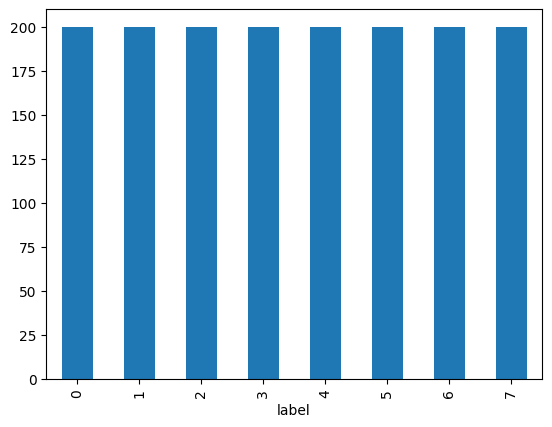

In [ ]:
df['label'].value_counts().plot(kind = 'bar')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   data    1600 non-null   object
 1   label   1600 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 25.1+ KB


In [ ]:
df = df.dropna(how = 'any')
print('전체 데이터 프레임:', df.isnull().values.any())

전체 데이터 프레임: False


In [ ]:
y= df['label']

In [ ]:
train_data = df.sample(frac=0.8, random_state=1)
test_data = df.drop(train_data.index)

In [ ]:
print('학습(train) 데이터의 수:', len(train_data))

학습(train) 데이터의 수: 1280


In [ ]:
print('학습(test) 데이터의 수 : ', len(test_data))

학습(test) 데이터의 수 :  320


In [ ]:
print('### 학습데이터의 라벨 분포 ###\n', train_data['label'].value_counts())

### 학습데이터의 라벨 분포 ###
 label
1    170
0    164
5    164
4    163
3    158
2    156
6    153
7    152
Name: count, dtype: int64


In [ ]:
print('### 테스트데이터의 라벨 분포 ###\n', test_data['label'].value_counts())

### 테스트데이터의 라벨 분포 ###
 label
7    48
6    47
2    44
3    42
4    37
0    36
5    36
1    30
Name: count, dtype: int64


In [ ]:
X_train = []
for i in tqdm(train_data.index):
  morph = okt.morphs(train_data.loc[i]['data'], stem=True) # stem=True : 어근 찾아오기
  temp_X = []
  for txt in morph:
    if txt not in stopword:
      temp_X.append(txt)
  X_train.append(temp_X)
X_train[:5]

In [ ]:
X_test = []
for i in tqdm(test_data.index):
  morph = okt.morphs(test_data.loc[i]['data'], stem=True) # stem=True : 어근 찾아오기
  temp_X = []
  for txt in morph:
    if txt not in stopword:
      temp_X.append(txt)
  X_test.append(temp_X)
X_test[:5]

In [ ]:
drop_train = []

for index, sentence in enumerate(X_train):
  if len(sentence) < 1:
    drop_train.append(index)
drop_train[:3]

[]

In [ ]:
len(drop_train)

0

In [ ]:
X_train = np.array(X_train, dtype=object)
X_train

y_train = np.array(train_data['label'])
y_train[:3]

array([0, 6, 2])

In [ ]:
X_train = np.delete(X_train, drop_train, axis=0)
y_train = np.delete(y_train, drop_train, axis=0)
print(len(X_train))
print(len(y_train))

1280
1280


In [ ]:
drop_test = []

for index, sentence in enumerate(X_test):
  if len(sentence) < 1:
    drop_test.append(index)
drop_test[:3]

[]

In [ ]:
X_test = np.array(X_test, dtype=object)
y_test = np.array(test_data['label'])

In [ ]:
X_test = np.delete(X_test, drop_test, axis=0)
y_test = np.delete(y_test, drop_test, axis=0)
print(len(X_test))
print(len(y_test))

320
320


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
print(tokenizer.word_index)

In [ ]:
threshold = 3
total_cnt = len(tokenizer.word_index)
rare_cnt = 0
total_freq = 0
rare_freq = 0

for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기:', total_cnt)
print(f'등장 빈도가 {threshold - 1}번 이하인 희귀 단어의 수:{rare_cnt}')
print(f'단어 집합에서 희귀 단어의 비율:{(rare_cnt / total_cnt)*100:.3f}')
print(f'전체 등장 빈도에서 희귀 단어 등장 빈도 비율:{(rare_freq / total_freq)*100:.3f}')

단어 집합(vocabulary)의 크기: 26238
등장 빈도가 2번 이하인 희귀 단어의 수:13662
단어 집합에서 희귀 단어의 비율:52.070
전체 등장 빈도에서 희귀 단어 등장 빈도 비율:4.496


In [ ]:
vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기:', vocab_size)

단어 집합의 크기: 12578


In [ ]:
tokenizer = Tokenizer(vocab_size, oov_token='OOV')
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_train[:3]

print(tokenizer.word_index)

문서의 최대 길이: 896
문서의 평균 길이: 303.20546875


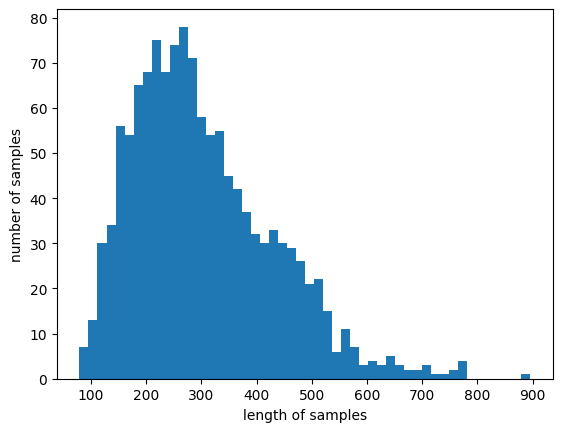

In [ ]:
print('문서의 최대 길이:', max(len(l) for l in X_train))
print('문서의 평균 길이:', sum(map(len, X_train)) / len(X_train))
plt.hist([len(s) for s in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [ ]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s) <= max_len):
      cnt = cnt + 1
  print(f'전체 샘플 중 길이가 {max_len} 이하인 샘플의 비율: {(cnt / len(nested_list))*100:.3f}')

In [ ]:
max_len = 500
below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 500 이하인 샘플의 비율: 92.344


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=max_len)

X_test = tokenizer.texts_to_sequences(X_test)
X_test = pad_sequences(X_test, maxlen=max_len)
print('X_train 크기:', X_train.shape)
print('X_test 크기:', X_test.shape)

X_train 크기: (1280, 500)
X_test 크기: (320, 500)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, LSTM, Embedding, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_LSTM = Sequential()
model_LSTM.add(Embedding(input_dim = vocab_size, output_dim = 64))
model_LSTM.add(LSTM(64, return_sequences = True))
model_LSTM.add(LSTM(32, return_sequences = False))
model_LSTM.add(Dense(32, activation = 'relu'))
model_LSTM.add(Dense(8, activation = 'softmax'))

In [ ]:
model_LSTM.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['acc'])

In [ ]:
model_LSTM.summary()

In [ ]:
es = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 4)
mc = ModelCheckpoint('best_model_LSTM.keras', monitor = 'val_acc', mode = 'max', verbose = 2, save_best_only = True)

history = model_LSTM.fit(X_train, y_train, epochs = 30, callbacks=[es, mc] , batch_size= 60, validation_split=0.2)

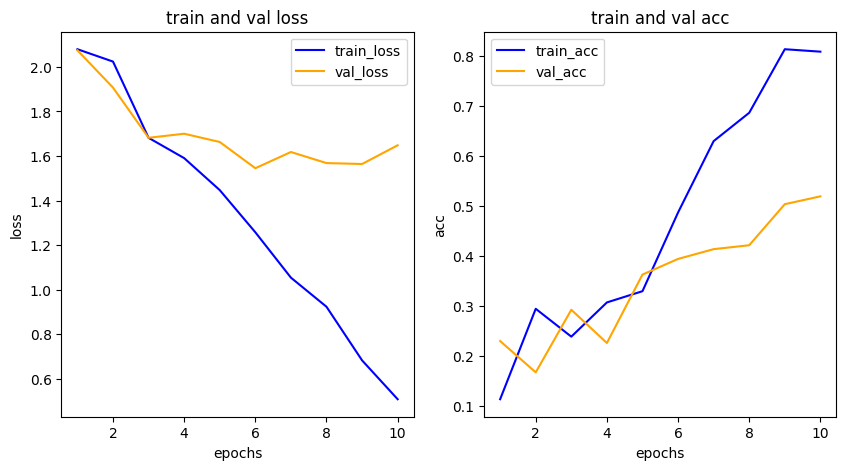

In [ ]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label='train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label='val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label='train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label='val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

In [ ]:
print('테스트 정확도:', model_LSTM.evaluate(X_test, y_test)[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.4219 - loss: 1.9601
테스트 정확도: 0.503125011920929


In [ ]:
loaded_model_LSTM= load_model('best_model_LSTM.keras')

In [ ]:
new_sentence = input('리뷰입력:')
new_sentence = okt.morphs(new_sentence)
new_sentence

리뷰입력:내가해도 이거보다 잘함


['내', '가해', '도', '이', '거', '보다', '잘', '함']

In [ ]:
new_sentence = [word for word in new_sentence if not word in stopword] # 불용어 제거
new_sentence

['가해', '보다', '함']

In [ ]:
encoded = tokenizer.texts_to_sequences(new_sentence) # 정수 인코딩
encoded

[[4816], [16], [1147]]

In [ ]:
pad_new = sequence.pad_sequences(encoded, maxlen=max_len) # 패딩
pad_new

array([[   0,    0,    0, ...,    0,    0, 4816],
       [   0,    0,    0, ...,    0,    0,   16],
       [   0,    0,    0, ...,    0,    0, 1147]], dtype=int32)

In [ ]:
score = float(sentiment_predict_LSTM.predict(pad_new))

In [ ]:
if (score < 1):
  print('해당 기사의 테마는 정치입니다.')
elif (score < 2):
  print('해당 기사의 테마는 경제입니다.')
elif (score < 3):
  print('해당 기사의 테마는 사회입니다.')
elif (score < 4):
  print('해당 기사의 테마는 생활/문화입니다.')
elif (score < 5):
 print('해당 기사의 테마는 세계입니다.')
elif (score < 6):
  print('해당 기사의 테마는 과학입니다.')
elif (score < 7):
  print('해당 기사의 테마는 연애입니다.')
elif (score < 8):
  print('해당 기사의 테마는 스포츠입니다.')
else:
  print('기사 없음')

In [ ]:
from tensorflow.keras.models import load_model
loaded_model_LSTM = load_model('best_model_LSTM.keras')

def sentiment_predict_LSTM(new_sentence):
  new_sentence = okt.morphs(new_sentence) # 토큰화
  new_sentence = [word for word in new_sentence if not word in stopword]
  encoded = tokenizer.texts_to_sequences([new_sentence]) # 정수 인코딩
  pad_new = sequence.pad_sequences(encoded, maxlen=max_len) # 패딩
  score = float(loaded_model_LSTM.predict(pad_new))
  if (score < 1):
    print('해당 기사의 테마는 정치입니다.')
  elif (score < 2):
    print('해당 기사의 테마는 경제입니다.')
  elif (score < 3):
    print('해당 기사의 테마는 사회입니다.')
  elif (score < 4):
    print('해당 기사의 테마는 생활/문화입니다.')
  elif (score < 5):
    print('해당 기사의 테마는 세계입니다.')
  elif (score < 6):
    print('해당 기사의 테마는 과학입니다.')
  elif (score < 7):
    print('해당 기사의 테마는 연애입니다.')
  elif (score < 8):
    print('해당 기사의 테마는 스포츠입니다.')
  else:
    print('기사 없음')

In [ ]:
sentiment_predict_LSTM('이정도면 많이 했다...졌지만 잘싸웠다')

In [ ]:
sentiment_predict_LSTM()

해당 기사의 테마는 생활/문화입니다.
